In [1]:
import pickle

In [5]:
savesimdir = '../results/simulations/pickles/'

In [6]:
N_range = [50]#[5, 10, 20, 50,  75, 100, 150,  250,  400, 500] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
linear_slope_variance_range = [0.1] #[0.0, 0.4, 0.8, 1.0]
linear_intercept_variance_range = [0.1] # [0.0, 0.4, 0.8, 1.0]
numcells_to_swap_range = [2] # , 16] #[0, 2, 8, 16, 64, 250]

In [3]:

import scanpy as sc 

import anndata

In [4]:

spa_celltype_key='cell_type'


scrna_cluster_key = "cell_type"


adata_sc = sc.read("../data/scrnaseq_raw.h5ad")

common_celltypes = ['Fibroblast',
 'Inhibitory Neuron',
 'Excitatory Neuron',
 'Oligodendrocyte',
 'Immune',
 'Tumor',
 'Astrocyte',
 'Endothelial']# define this according to dataset

In [ ]:
adata_sc.write("scrnaseq_raw_cell2loc.h5ad")

In [7]:
adata_sc

AnnData object with n_obs × n_vars = 9855 × 241
    obs: 'cell_type', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cell_type_colors'
    obsm: 'CovMatsTrans', 'envi_latent', 'latent_umap', 'umap'

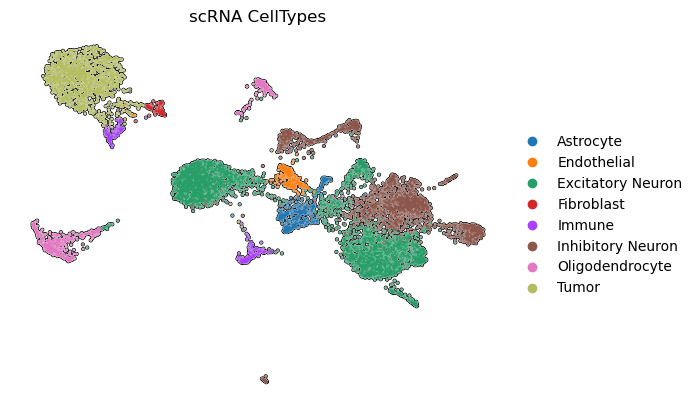

In [8]:
sc.pl.embedding(adata_sc,'umap',color='cell_type', add_outline=True, frameon=False,title='scRNA CellTypes',save='_scRNAcelltypes_tmpa.pdf')

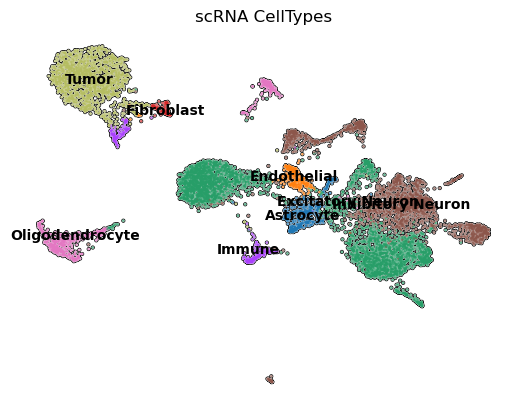

In [14]:
sc.pl.embedding(adata_sc,'umap',color='cell_type', add_outline=True, frameon=False,title='scRNA CellTypes',legend_loc='on data',save='_scRNAcelltypes.pdf')

In [ ]:
# perform QC for reference based on 1st spatial sample 


save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N_range[0]) + '_linear_slope_var_' + str(linear_slope_variance_range[0]) + '_linear_int_var_' + str(linear_intercept_variance_range[0]) + '_' + str(numcells_to_swap_range[0]) + '.pickle'

with open(save_sim_file, 'rb') as handle:
    tmpa = pickle.load(handle)  
entry0 = list(tmpa.keys())[0]
entry1 = list(tmpa[entry0].keys())[0]
entry2 = list(tmpa[entry0][entry1].keys())[0]

genes_to_use = list((set(tmpa[entry0][entry1][entry2].var.index).intersection(set(adata_sc.var.index))))
print(len(genes_to_use))
genes_to_use.sort()

print(adata_sc.to_df().sum(axis=1).median())

adata_sc =  anndata.AnnData(X=adata_sc.to_df()[genes_to_use],obs=adata_sc.obs,uns=adata_sc.uns,obsm=adata_sc.obsm)
sc.pp.filter_cells(adata_sc,min_counts=1)

print(adata_sc.to_df().sum(axis=1).median())

sc.pp.normalize_total(adata_sc, target_sum=1000)

print(adata_sc.to_df().sum(axis=1).median())

# sc.pp.log1p(adata_sc)

print(adata_sc.to_df().sum(axis=1).median())

adata_sc = adata_sc[adata_sc.obs[scrna_cluster_key].isin(common_celltypes)]




if adata_sc.shape[1] > 1500:
    
    sc.tl.rank_genes_groups(adata_sc, groupby=scrna_cluster_key, method="wilcoxon")
    sc.tl.filter_rank_genes_groups(adata_sc,   key_added='rank_genes_groups_filtered',  min_fold_change=1.5)
    all_genes = sc.get.rank_genes_groups_df(adata_sc,group=None, key='rank_genes_groups_filtered', pval_cutoff=0.05, log2fc_min=1.5)
    all_genes = all_genes[~all_genes['names'].isna()]
    adata_sc = adata_sc[:,list(set(all_genes['names']))]
    disp_columns = []
    for ct in set(adata_sc.obs[scrna_cluster_key].values):
        adata_sc.var[ct + '_disperson'] = 0.0
        disp_columns.append(ct + '_disperson')
        tmpa = adata_sc[adata_sc.obs[scrna_cluster_key]==ct].copy()

        tmpb = tmpa.to_df().var() / (tmpa.to_df().mean() + 0.000001)

        adata_sc.var[ct + '_disperson'] = tmpb


    adata_sc.var['avg_dispersion'] = adata_sc.var[disp_columns].mean(axis=1)
    import numpy as np
    top_pct = np.quantile(a=adata_sc.var['avg_dispersion'], q=0.99)

    adata_sc = adata_sc[:,adata_sc.var['avg_dispersion'] < top_pct]
    
# del adata_sc.uns
adata_sc.write_h5ad("../data/scrna_ref_norm1knolog.h5ad")



241
14.0
14.0
1000.0
1000.0


In [ ]:

#cnt = 0

nneigh_range = [10]
N_range = [25,  75,  125, 150, 175] # [5, 10, 50,  100,  200,  400] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
nswaps_nbd_range = [2] # [2, 5, 10, 20, 50, 100]

for N in N_range:
        # for linear_slope_variance in linear_slope_variance_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        #     for linear_intercept_variance in linear_intercept_variance_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        for nneigh in nneigh_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
            for nbdswaps in nswaps_nbd_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
                # for numcells_to_swap in numcells_to_swap_range:#[0, 2, 4, 8, 16, 32, 64, 128, 256]:
                    # save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '.pickle'
                    # write_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '_normnolog_nov2024_1k.pickle'
                    save_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '.pickle'
                    write_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_norm1knolog.pickle'
                    
                    
                    with open(save_sim_file, 'rb') as handle:
                        adata_spot_swap = pickle.load(handle)

                    for entry0 in adata_spot_swap.keys():
                        for entry1 in adata_spot_swap[entry0].keys(): 
                            for entry2 in adata_spot_swap[entry0][entry1].keys():
                                #adata_st = adata_spot_swap[entry0][entry1][entry2].copy()
                                



                                genes_to_use = list((set(adata_sc.var.index).intersection(set(adata_spot_swap[entry0][entry1][entry2].var.index))))
                                # print(len(genes_to_use))
                                genes_to_use.sort()

                                # # adata_sc_curr = adata_sc.copy()
                                

                                # # adata_st = adata_st.copy()
                                adata_st =  anndata.AnnData(X=adata_spot_swap[entry0][entry1][entry2].to_df()[genes_to_use],obs=adata_spot_swap[entry0][entry1][entry2].obs,uns=adata_spot_swap[entry0][entry1][entry2].uns,obsm=adata_spot_swap[entry0][entry1][entry2].obsm)


                                print(adata_st.to_df().sum(axis=1).median())
                                
                                # adata_st = adata_spot_swap[entry0][entry1][entry2].copy()

                                sc.pp.normalize_total(adata_st, target_sum=1000)

                                

                                print(adata_st.to_df().sum(axis=1).median())


                                
                                # common_celltypes = set(common_celltypes).union(set(adata_st.obs['spa_celltype_key']))
                                adata_spot_swap[entry0][entry1][entry2] = adata_st.copy()
                                # print(adata_spot_swap[entry0][entry1][entry2].shape)

                    with open(write_sim_file, 'wb') as handle:
                        pickle.dump(adata_spot_swap, handle, protocol=pickle.HIGHEST_PROTOCOL)
        


















3675.0
1000.0
3686.0
1000.0
3672.5
1000.0
3670.0
1000.0000000000001
3671.0
1000.0
3651.0
1000.0
3656.0
1000.0
3643.5
1000.0
3653.0
1000.0
3641.0
1000.0
3646.5
1000.0
10947.0
1000.0
10961.0
1000.0
10940.0
1000.0
10970.0
1000.0
10962.0
1000.0
10962.0
1000.0
10958.0
1000.0
10949.0
1000.0
10904.0
1000.0
10915.0
1000.0
10944.0
1000.0
18259.0
1000.0
18249.0
1000.0
18261.0
1000.0
18248.0
1000.0
18243.0
1000.0
18218.0
1000.0
18225.0
1000.0
18255.0
1000.0
18277.0
1000.0
18277.0
1000.0
18265.0
1000.0
21422.0
1000.0
21442.5
1000.0
21442.5
1000.0
21391.0
1000.0000000000001
21421.5
1000.0
21404.0
1000.0
21454.0
1000.0
21426.5
999.9999999999999
21402.5
1000.0
21420.0
1000.0
21390.0
1000.0
24743.0
1000.0
24578.0
1000.0
24578.0
1000.0
24619.0
1000.0
24758.0
1000.0
24758.0
1000.0
24771.0
1000.0
24615.0
1000.0
24615.0
1000.0
24615.0
1000.0
24561.0
1000.0


## get raw for CARD cell2location

In [ ]:
import scanpy as sc

adata_sc_raw  = sc.read("../data/scrnaseq_raw.h5ad")

adata_sc = sc.read( "../data/scrna_ref_norm1knolog.h5ad")

print(adata_sc_raw.shape, adata_sc.shape)
adata_sc_raw = adata_sc_raw[adata_sc.obs.index,adata_sc.var.index]

print(adata_sc_raw.shape, adata_sc.shape)


adata_sc_raw.to_df().to_csv("../data/scrnaseq_raw.csv")

adata_sc_raw.obs.to_csv("../data/scrnaseq_metadata.csv")


adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

(9870, 241) (9855, 241)
(9855, 241) (9855, 241)


In [26]:
adata_sc_raw  = adata_sc_raw.copy()
for entry in ['cluster_genes', 'hvg', 'rank_genes_groups']:
    del adata_sc_raw.uns[entry]


adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

In [28]:
adata_sc_raw

AnnData object with n_obs × n_vars = 9855 × 241
    obs: 'cell_type', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cell_type_colors'
    obsm: 'CovMatsTrans', 'envi_latent', 'latent_umap', 'umap'